# Immowelt Scraper

Clean HTTP-based scraper - no Selenium needed!

# Import session data from browser session

### 1) Get session data from existing browser session in developer tools
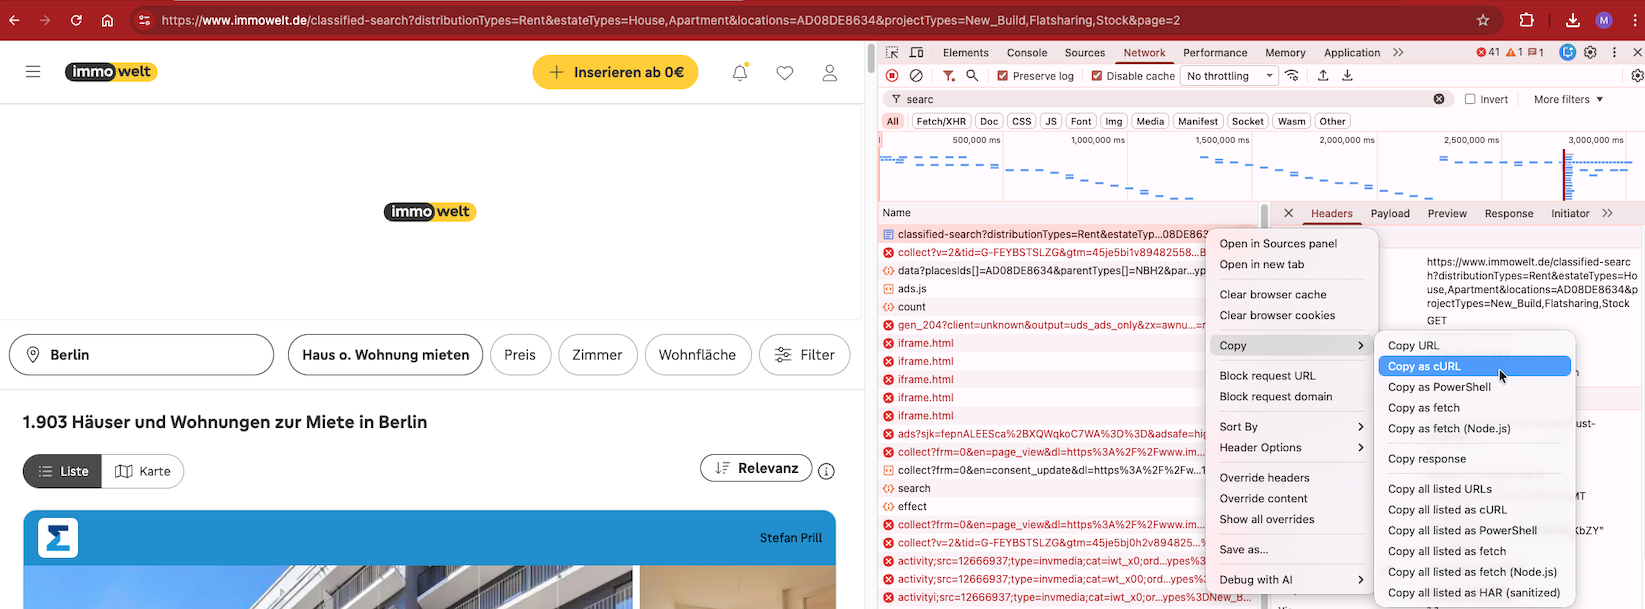

### 2) Paste session data
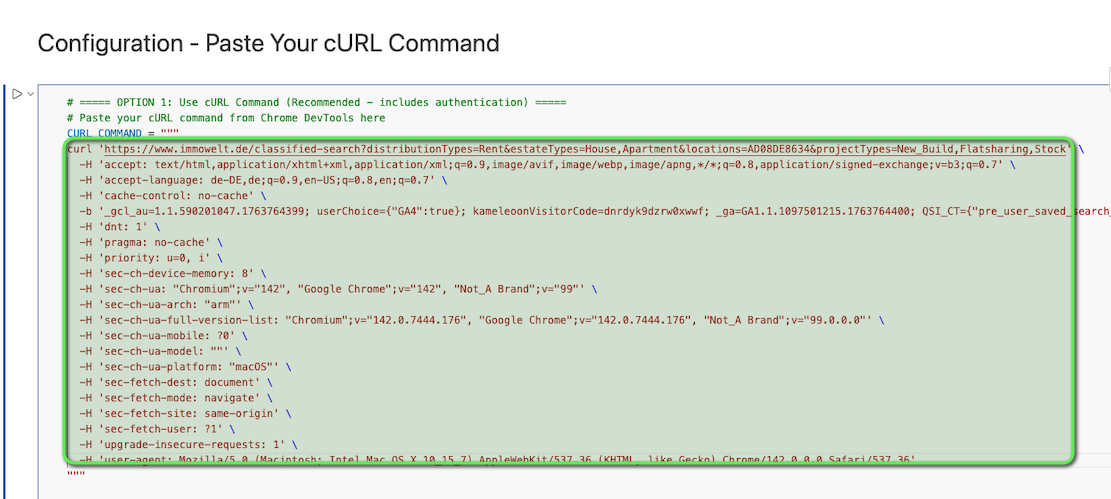

In [1]:
import re, time, random
from typing import List, Dict, Optional
from urllib.parse import urlparse, parse_qs

import requests
import pandas as pd
from bs4 import BeautifulSoup
from tqdm import tqdm

## Scraper Class

In [2]:
class ImmoweltScraper:
    """Immowelt scraper using HTTP requests - fast and reliable!"""

    def __init__(self, curl_command: str = None, base_url: str = None, 
                 headers: Dict = None, cookies: Dict = None, delay_range: tuple = (3, 6)):
        self.delay_range = delay_range
        self.scraped_data = []

        # Option 1: Parse from cURL command (recommended - includes auth)
        if curl_command:
            config = self._parse_curl(curl_command)
            self.base_url = config['base_url']
            self.params = config['params']
            
            self.session = requests.Session()
            self.session.headers.update(config['headers'])
            self.session.cookies.update(config['cookies'])
            
            print(f"✓ Initialized from cURL with {len(config['cookies'])} cookies, {len(config['headers'])} headers")
        
        # Option 2: Simple URL template (for basic usage without auth)
        elif base_url:
            parsed_url = urlparse(base_url.replace('{page}', '1'))
            self.base_url = f"{parsed_url.scheme}://{parsed_url.netloc}{parsed_url.path}"
            self.params = {k: v[0] for k, v in parse_qs(parsed_url.query).items()}
            
            self.session = requests.Session()
            if headers:
                self.session.headers.update(headers)
            if cookies:
                self.session.cookies.update(cookies)
            
            print(f"✓ Initialized from URL template")
        
        else:
            raise ValueError("Must provide either curl_command or base_url")

    def _parse_curl(self, cmd: str) -> Dict:
        """Parse cURL command to extract URL, headers, and cookies"""
        c = cmd.replace('\\\n', ' ').strip()

        # Extract URL
        url = re.search(r"curl\s+['\"]?([^'\"]+?)['\"]?\s+(?:-|$)", c).group(1)

        # Extract headers (skip cookie header)
        headers = {}
        for m in re.finditer(r"-H\s+['\"]([^:]+):\s*([^'\"]+)['\"]", c):
            if m.group(1).lower() != 'cookie':
                headers[m.group(1).strip()] = m.group(2).strip()

        # Extract cookies from both -b flag and -H cookie header
        cookies = {}
        for pattern in [r"(?:-b|--cookie)\s+['\"](.+?)['\"](?:\s|$)",
                       r"-H\s+['\"]cookie:\s*([^'\"]+)['\"]"]:
            m = re.search(pattern, c, re.I)
            if m:
                for pair in m.group(1).split(';'):
                    if '=' in pair:
                        k, v = pair.split('=', 1)
                        cookies[k.strip()] = v.strip()

        # Parse URL components
        parsed_url = urlparse(url)
        return {
            'base_url': f"{parsed_url.scheme}://{parsed_url.netloc}{parsed_url.path}",
            'params': {k: v[0] for k, v in parse_qs(parsed_url.query).items()},
            'headers': headers,
            'cookies': cookies
        }

    def scrape_page(self, page_num: int) -> Optional[str]:
        """Fetch a single page HTML"""
        params = self.params.copy()
        params['page'] = str(page_num)

        try:
            response = self.session.get(self.base_url, params=params, timeout=30)
            return response.text if response.status_code == 200 else None
        except Exception as e:
            print(f"Error page {page_num}: {e}")
            return None

    def extract_data(self, html: str, page_num: int) -> List[Dict]:
        """Extract listing data from HTML"""
        soup = BeautifulSoup(html, 'lxml')
        links = soup.select('a[data-testid="card-mfe-covering-link-testid"]')
        images = soup.select('img[alt]')  # Images with alt text

        listings = []
        for i, link in enumerate(links):
            try:
                detail_url = link.get('href', '')
                title_attr = link.get('title', '')

                # Find matching image by looking for property info in alt text
                alt_text = ''
                for img in images:
                    alt = img.get('alt', '')
                    # Check if this image's alt text contains property info
                    if alt and any(word in alt for word in ['Wohnung', 'Haus', 'Zimmer']):
                        alt_text = alt
                        images.remove(img)  # Remove so next listing gets next image
                        break

                # Use alt_text if available, otherwise fall back to title
                info_str = alt_text if alt_text else title_attr

                listings.append({
                    'detail_url': detail_url,
                    'raw_info': info_str
                })
            except Exception as e:
                print(f"Error parsing a listing: {e}")

        return listings

    def detect_total_pages(self, html: str) -> int:
        """Auto-detect total number of pages from pagination nav"""
        soup = BeautifulSoup(html, 'lxml')
        
        # Find pagination nav and look for page number buttons
        nav = soup.find('nav', {'aria-label': 'pagination navigation'})
        if nav:
            # Find all buttons with aria-label like "zu seite X"
            page_numbers = []
            for button in nav.find_all('button'):
                aria_label = button.get('aria-label', '')
                # Match patterns like "zu seite 64" or "aktuelle seite, seite 1"
                match = re.search(r'seite\s+(\d+)', aria_label, re.I)
                if match:
                    page_numbers.append(int(match.group(1)))
            
            # Return the highest page number found
            if page_numbers:
                return max(page_numbers)
        
        # Fallback to 65 if detection fails
        return 4

    def save_data(self, filename: str, fmt: str = "csv"):
        """Save scraped data to file"""
        if not self.scraped_data:
            print("No data to save")
            return

        df = pd.DataFrame(self.scraped_data)
        if fmt.lower() == "csv":
            df.to_csv(filename, index=False)
        elif fmt.lower() == "json":
            df.to_json(filename, orient="records", indent=2)
        elif fmt.lower() == "excel":
            df.to_excel(filename, index=False)

        print(f"✓ Saved {len(df)} listings to {filename}")

    def run_scraper(self, start_page: int = 1, end_page: Optional[int] = None):
        """Main scraping loop with progress bar"""
        # Store start/end for filename
        self.start_page = start_page
        
        # Fetch first page
        first_page_html = self.scrape_page(start_page)
        if not first_page_html:
            print("Failed to fetch first page!")
            return

        # Auto-detect total pages
        if end_page is None:
            end_page = self.detect_total_pages(first_page_html)
            print(f"Auto-detected {end_page} pages")
        
        self.end_page = end_page

        # Extract first page
        self.scraped_data.extend(self.extract_data(first_page_html, start_page))

        # Scrape remaining pages with progress bar
        for page in tqdm(range(start_page + 1, end_page + 1), desc="Scraping"):
            time.sleep(random.uniform(*self.delay_range))
            html = self.scrape_page(page)
            if html:
                self.scraped_data.extend(self.extract_data(html, page))

        print(f"\n✓ Scraped {len(self.scraped_data)} total listings")

    def close(self):
        """Close HTTP session"""
        self.session.close()

print("✓ ImmoweltScraper class defined")

✓ ImmoweltScraper class defined


## Configuration - Paste Your cURL Command

In [ ]:
# ===== OPTION 1: Use cURL Command (Recommended - includes authentication) =====
# Paste your cURL command from Chrome DevTools here
CURL_COMMAND = """

"""

# Initialize with cURL
scraper = ImmoweltScraper(curl_command=CURL_COMMAND, delay_range=(3, 6))


# ===== OPTION 2: Simple URL Template (Basic usage - may get blocked without cookies) =====
# Uncomment this section to use simple URL template instead:

# base_url_template = (
#     "https://www.immowelt.de/classified-search"
#     "?distributionTypes=Rent"
#     "&estateTypes=House,Apartment"
#     "&locations=AD08DE8634"
#     "&projectTypes=New_Build,Flatsharing,Stock"
#     "&page={page}"
# )
# 
# scraper = ImmoweltScraper(base_url=base_url_template, delay_range=(3, 6))

✓ Initialized from cURL with 3 cookies, 19 headers


## Run Scraper

In [4]:
# Run scraper (auto-detects ~64 pages)
start_page = 1
end_page = None  # None = auto-detect, or specify number like 4 for testing

scraper.run_scraper(start_page=start_page, end_page=end_page)

# Generate filename based on actual pages scraped
output_filename = f"immowelt_pages_{scraper.start_page}_{scraper.end_page}.csv"
scraper.save_data(output_filename, fmt="csv")

# Cleanup
scraper.close()

print(f"\n✅ Done! Saved to {output_filename}")

Auto-detected 64 pages


Scraping: 100%|██████████| 63/63 [05:52<00:00,  5.60s/it]


✓ Scraped 2015 total listings
✓ Saved 2015 listings to immowelt_pages_1_64.csv

✅ Done! Saved to immowelt_pages_1_64.csv


## View Results

In [6]:
# Load and preview data
df = pd.DataFrame(scraper.scraped_data)

print(f"Total listings: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")

df.head(10)

Total listings: 2015

Columns: ['detail_url', 'raw_info']


,detail_url,raw_info
0,https://www.immowelt.de/expose/dab515fc-44d3-4...,Wohnung zur Miete 849 € 1 Zimmer 30 m² 2. Gesc...
1,https://www.immowelt.de/expose/ccddf31e-7753-4...,"Wohnung zur Miete 889 € 1 Zimmer 29,6 m² 4. Ge..."
2,https://www.immowelt.de/expose/4d8c7088-40dd-4...,"Studio zur Miete 564 € 1 Zimmer 21,5 m² 4. Ges..."
3,https://www.immowelt.de/expose/529dbdda-c9db-4...,"Studio zur Miete 900 € 1 Zimmer 28,9 m² 1. Ges..."
4,https://www.immowelt.de/expose/8404f011-be75-4...,"Studio zur Miete 575 € 1 Zimmer 18,8 m² 2. Ges..."
5,https://www.immowelt.de/expose/90252e70-ed09-4...,Studio zur Miete 679 € 1 Zimmer 36 m² 2. Gesch...
6,https://www.immowelt.de/expose/d044d091-1b5c-4...,Studio zur Miete 884 € 1 Zimmer 24 m² 8. Gesch...
7,https://www.immowelt.de/expose/ce9129a0-9a31-4...,Wohnung zur Miete - Erstbezug 2.360 € 2 Zimmer...
8,https://www.immowelt.de/projekte/expose/k25f932,Wohnung zur Miete - Erstbezug 1.665 € 2 Zimmer...
9,https://www.immowelt.de/projekte/expose/k2m6932,"Wohnung zur Miete 1.450 € 2 Zimmer 62,4 m² 2. ..."
